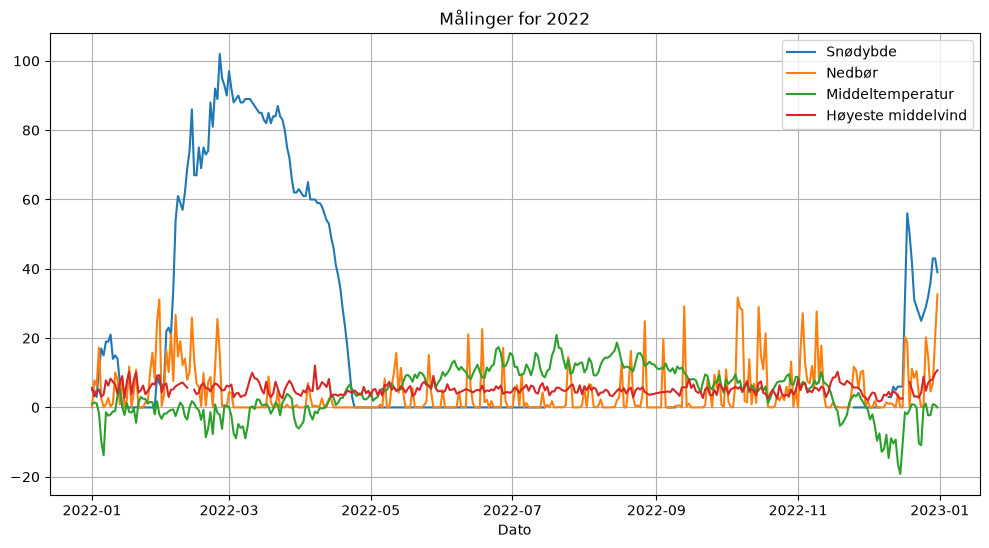

In [ ]:
import csv
from datetime import datetime
import matplotlib.pyplot as plt

# Lister for alle målinger
datoer = []
middeltemp = []
nedbor = []
vind = []
sno = []

# --- LES CSV-FILA ---
with open("sinnes_2014_2025.csv", "r", encoding="utf-8") as f:
    reader = csv.reader(f, delimiter=';')
    next(reader)

    for rad in reader:
    
        try:
            d = datetime.strptime(rad[2], "%d.%m.%Y")
        except:
            continue 

        
        def conv(x):
            x = x.replace(",", ".")
            return float(x) if x not in ["", "-"] else None

        datoer.append(d)
        middeltemp.append(conv(rad[3]))
        nedbor.append(conv(rad[4]))
        vind.append(conv(rad[5]))
        sno.append(conv(rad[6]))



def filter_ar(year):
    dato_f = []
    temp_f = []
    nedbor_f = []
    vind_f = []
    sno_f = []

    for d, t, n, v, s in zip(datoer, middeltemp, nedbor, vind, sno):
        if d.year == year:
            dato_f.append(d)
            temp_f.append(t)
            nedbor_f.append(n)
            vind_f.append(v)
            sno_f.append(s)

    return dato_f, temp_f, nedbor_f, vind_f, sno_f



def plot_ar(year):
    dato_f, temp_f, nedbor_f, vind_f, sno_f = filter_ar(year)

    if not dato_f:
        print(f"Ingen målinger for {year}")
        return

    plt.figure(figsize=(12,6))
    plt.plot(dato_f, sno_f, label="Snødybde")
    plt.plot(dato_f, nedbor_f, label="Nedbør")
    plt.plot(dato_f, temp_f, label="Middeltemperatur")
    plt.plot(dato_f, vind_f, label="Høyeste middelvind")

    plt.legend()
    plt.title(f"Målinger for {year}")
    plt.xlabel("Dato")
    plt.grid(True)
    plt.show()


plot_ar(2022)
